#1. Importing Modules and Loading Dataset

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense


In [20]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

#2. Loading and Normalizing Image Data

In [21]:
gray_scale=255

x_train=x_train.astype('float32')/gray_scale
x_test=x_train.astype('float32')/gray_scale

print("Feature matrix (x_train):",x_train.shape)
print("Target matrix (x_train):",y_train.shape)

print("Feature matrix (x_test):",x_test.shape)
print("Target matrix (y_test):",y_test.shape)


Feature matrix (x_train): (60000, 28, 28)
Target matrix (x_train): (60000,)
Feature matrix (x_test): (60000, 28, 28)
Target matrix (y_test): (10000,)


#3. Visualizing Data

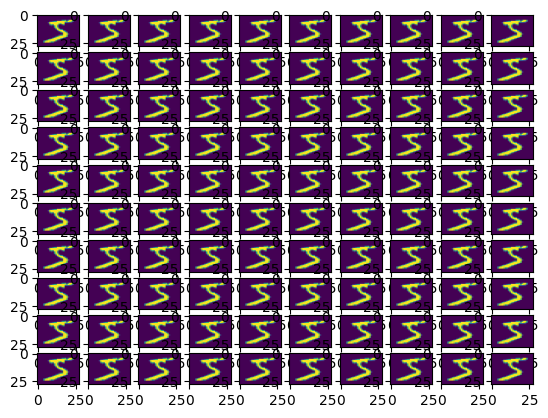

In [22]:
fig,ax=plt.subplots(10,10)
k=0
for i in range(10):
   for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
plt.show()


#4. Building the Neural Network Model

In [23]:
model=Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(10, activation='softmax'),

])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#6. Training the Model

In [24]:
mod = model.fit(x_train, y_train, epochs=10,
          batch_size=2000,
          validation_split=0.2)

print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.3831 - loss: 2.0960 - val_accuracy: 0.6244 - val_loss: 1.7523
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.7232 - loss: 1.4215 - val_accuracy: 0.8005 - val_loss: 1.0693
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8202 - loss: 0.8880 - val_accuracy: 0.8597 - val_loss: 0.6871
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8631 - loss: 0.6184 - val_accuracy: 0.8874 - val_loss: 0.5089
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8844 - loss: 0.4854 - val_accuracy: 0.8994 - val_loss: 0.4177
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8959 - loss: 0.4118 - val_accuracy: 0.9073 - val_loss: 0.3641
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9047 - loss: 0.3653 - val_accuracy: 0.9134 - val_loss: 0.3298
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9113 - loss: 0.3325 - val_accuracy: 0.9182 -

#7. Evaluating the Model

In [25]:
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

x_test shape: (60000, 28, 28)
y_test shape: (10000,)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 60000
'y' sizes: 10000


#8. Visualizing Training and Validation Loss VS Accuracy

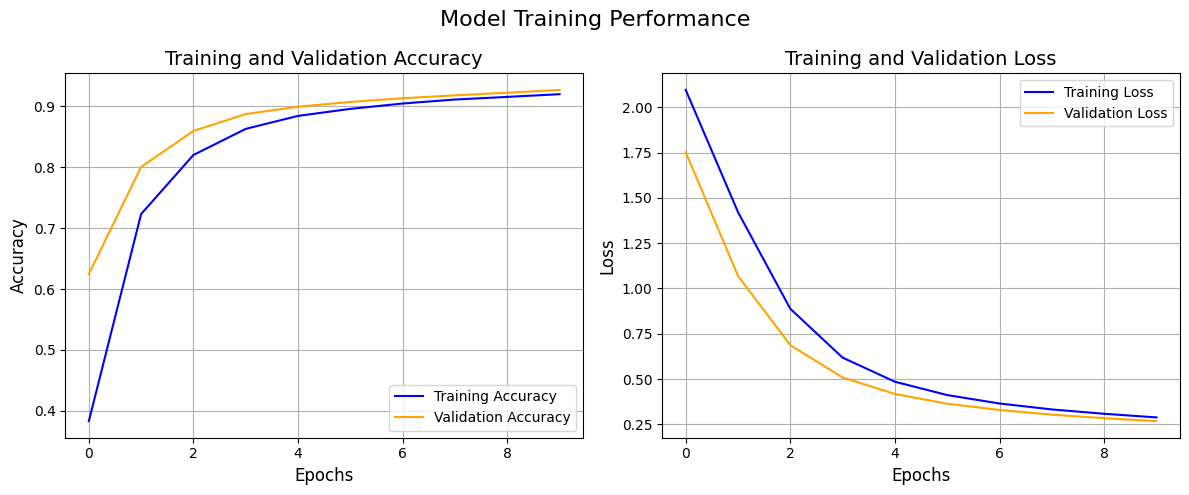

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()